In [53]:
import pandas as pd

import numpy as np
from scipy.stats import spearmanr
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_parquet("train_team_track.parquet", engine='fastparquet')

In [79]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4342000 entries, 0 to 4341999
Data columns (total 12 columns):
 #   Column          Dtype         
---  ------          -----         
 0   office_from_id  int64         
 1   route_id        int64         
 2   timestamp       datetime64[ns]
 3   status_1        int64         
 4   status_2        int64         
 5   status_3        int64         
 6   status_4        int64         
 7   status_5        int64         
 8   status_6        int64         
 9   status_7        int64         
 10  status_8        int64         
 11  target_2h       float64       
dtypes: datetime64[ns](1), float64(1), int64(10)
memory usage: 397.5 MB


In [109]:
df.isna().sum()

office_from_id    0
route_id          0
timestamp         0
status_1          0
status_2          0
status_3          0
status_4          0
status_5          0
status_6          0
status_7          0
status_8          0
target_2h         0
day               0
dtype: int64

Нет ни нулевых значений, ни категориальных данных

In [3]:
df.head()

,office_from_id,route_id,timestamp,status_1,status_2,status_3,status_4,status_5,status_6,status_7,status_8,target_2h
0,4,29,2025-03-01 00:00:00,3105,340,2160,484,4018,3462,0,0,27.0
1,4,29,2025-03-01 00:30:00,2813,388,2058,373,1363,1657,9380,0,27.0
2,4,29,2025-03-01 01:00:00,2465,293,2098,472,3195,3325,0,0,23.0
3,4,29,2025-03-01 01:30:00,1977,252,2351,310,3314,3243,0,0,37.0
4,4,29,2025-03-01 02:00:00,1585,206,2500,300,2130,1604,0,0,31.0


In [133]:
pd.to_datetime(df['timestamp']).dt.hour

0           0
1           0
2           1
3           1
4           2
           ..
4341995     8
4341996     9
4341997     9
4341998    10
4341999    10
Name: timestamp, Length: 4342000, dtype: int32

In [85]:
variable_features = df.columns[3:]
static_features = df.columns[:2]

In [50]:
print(f"Количество уникальных route_id: {df['route_id'].nunique()}")
print(f"Количество уникальных office_from_id: {df['office_from_id'].nunique()}")
print(f"Количество уникальных пар (route_id, office_from_id): {df[['route_id', 'office_from_id']].drop_duplicates().shape[0]}")

Количество уникальных route_id: 1000
Количество уникальных office_from_id: 53
Количество уникальных пар (route_id, office_from_id): 1000


In [51]:
routes_with_offices = df.groupby('office_from_id')['route_id'].nunique()
routes_with_offices[routes_with_offices != 1]

office_from_id
1     54
2     18
3     27
4      7
5      4
6     10
7     13
8      7
9      2
10    57
11     9
12    61
13    64
14     9
15    15
17     5
18    13
19    23
20     4
21    43
22    50
23    20
24    21
25    34
26    10
27     2
28    27
29    32
30     7
31     9
32     6
33    49
34    11
35     6
36    18
37    12
38    13
39    16
40    13
41    55
42    22
43    23
44     6
45    12
46    12
47     2
48     8
49     7
50    13
51     7
52     6
53    25
Name: route_id, dtype: int64

Каждому складу принадлежит несколько маршрутов, но каждому маршруту принадлежит один склад

In [76]:
amount_rows_in_routes_with_office = df.groupby(['office_from_id', 'route_id']).size()
amount_rows_in_routes_with_office[amount_rows_in_routes_with_office != 4342]

Series([], dtype: int64)

Все группы склад-маршрут имеют одинаковый размер

In [73]:
timestamps = df.groupby(['office_from_id', 'route_id'])['timestamp'].agg(['first', 'last'])
timestamps[(timestamps['first']!=timestamps.iloc[0]['first']) | (timestamps['last']!=timestamps.iloc[0]['last'])]

,,first,last
office_from_id,route_id,,


In [111]:
print(f"Начальное время отследивания: {timestamps.iloc[0]['first']}")
print(f"Конечное время отследивания: {timestamps.iloc[0]['last']}")

Начальное время отследивания: 2025-03-01 00:00:00
Конечное время отследивания: 2025-05-30 10:30:00


Во всех группах склад-маршрут время началное и конечное время одинаковы

Можно отметить, что даты приходятся на праздники: 8 марта, 1 апреля, 1 мая, 9 мая

In [80]:
df['day'] = pd.to_datetime(df['timestamp']).dt.dayofweek

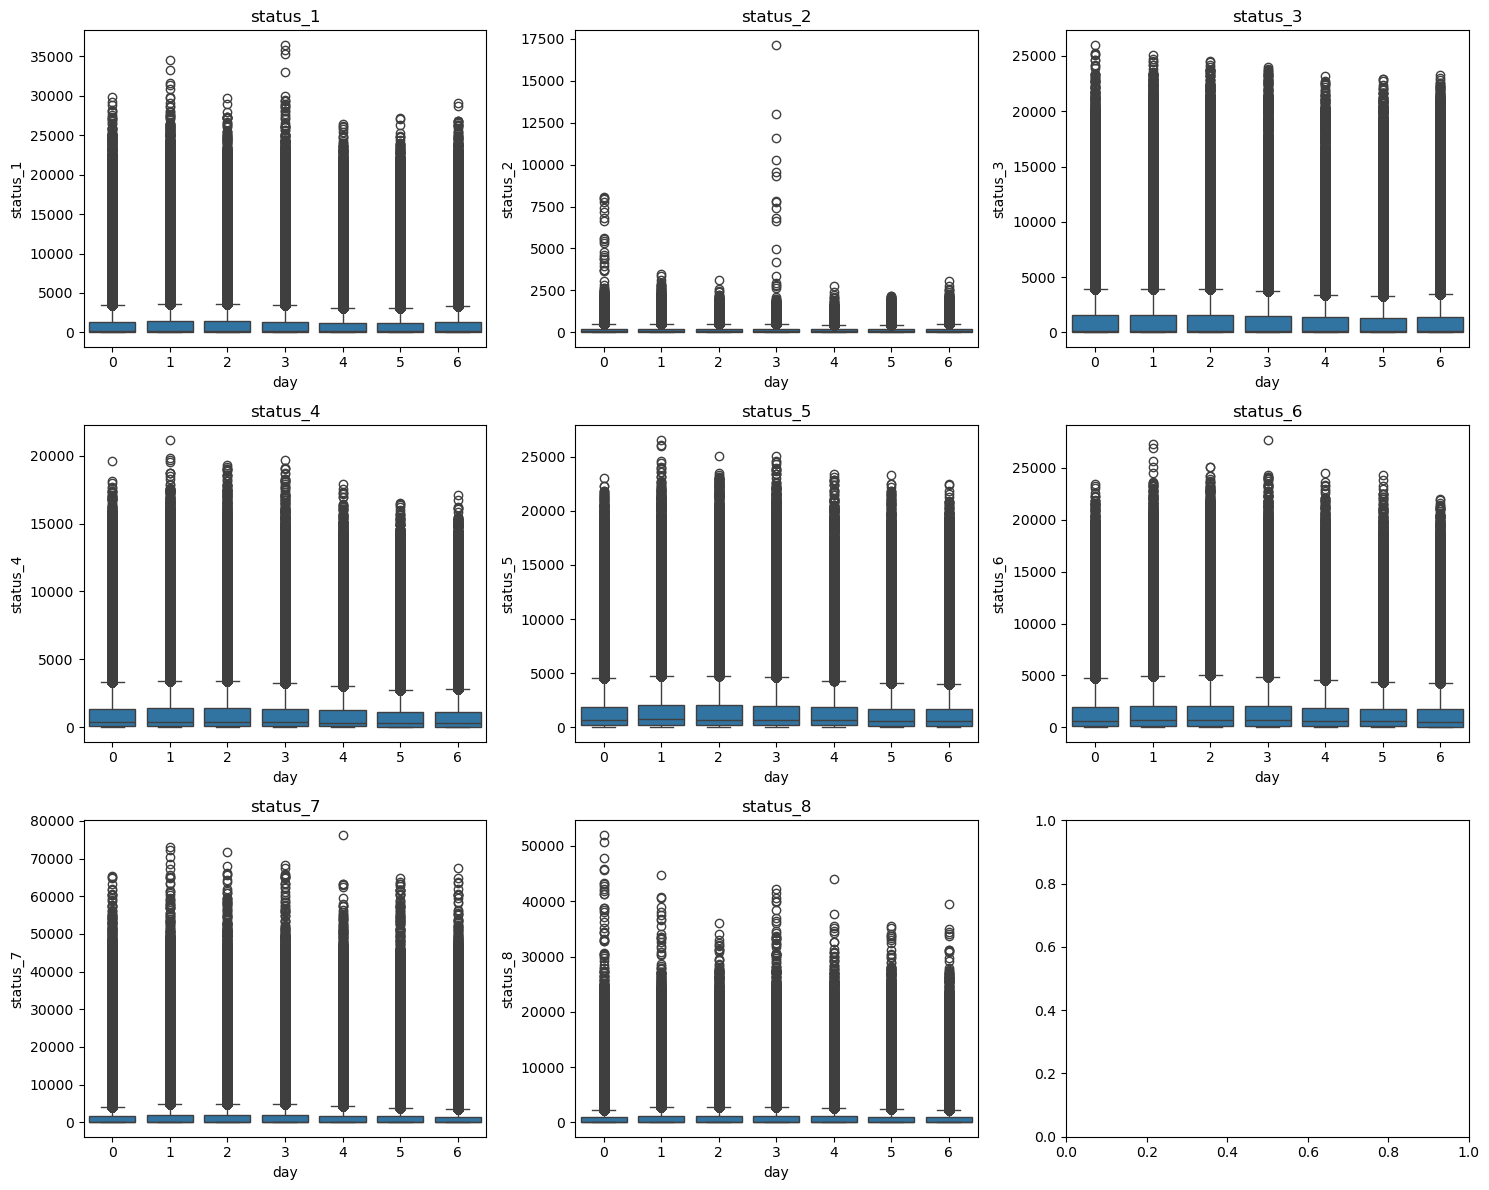

In [82]:
status_cols = ['status_1', 'status_2', 'status_3', 'status_4', 
               'status_5', 'status_6', 'status_7', 'status_8']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, status in enumerate(status_cols):
    sns.boxplot(data=df, x='day', y=status, ax=axes[i])
    axes[i].set_title(status)

plt.tight_layout()
plt.show()

In [106]:
pd.set_option('display.max_columns', None)
descr = df.groupby('day')[variable_features[:-1]].describe()
descr.index = descr.index.map({0:'Mon', 1:'Tue', 2:'Wed', 3:'Thu', 4:'Fri', 5:'Sat', 6:'Sun'})
print(descr)
pd.set_option('display.max_columns',20)

     status_1                                                              \
        count         mean          std  min  25%    50%     75%      max   
day                                                                         
Mon  624000.0  1339.398255  2562.410211  0.0  0.0  122.0  1370.0  29885.0   
Tue  624000.0  1381.849329  2616.829978  0.0  0.0  131.0  1437.0  34601.0   
Wed  624000.0  1351.581670  2545.004612  0.0  0.0  131.0  1417.0  29678.0   
Thu  624000.0  1311.124059  2475.039487  0.0  0.0  128.0  1372.0  36491.0   
Fri  598000.0  1205.462968  2292.531959  0.0  0.0  119.0  1244.0  26458.0   
Sat  624000.0  1224.907486  2352.516616  0.0  0.0  112.0  1238.0  27255.0   
Sun  624000.0  1356.530444  2634.255571  0.0  0.0  116.0  1348.0  29150.0   

     status_2                                                           \
        count        mean         std  min   25%   50%    75%      max   
day                                                                      
Mon  62

Сильный разброс, медиана во всех статусах в разы меньше среднего. Но можно отметить, что со вторника по среду наблюдается прирост по всем статусам, а также прирост по таргету. 

In [90]:
df.iloc[1599299:1599310]

,office_from_id,route_id,timestamp,status_1,status_2,status_3,status_4,status_5,status_6,status_7,status_8,target_2h,day
1599299,43,298,2025-03-31 01:30:00,29885,2,3354,408,343,1034,0,0,6.0,0
1599300,43,298,2025-03-31 02:00:00,474,3,13480,443,274,0,0,0,6.0,0
1599301,43,298,2025-03-31 02:30:00,381,0,8082,1064,310,440,0,0,9.0,0
1599302,43,298,2025-03-31 03:00:00,160,2,2555,1374,324,0,0,0,6.0,0
1599303,43,298,2025-03-31 03:30:00,104,0,1323,1678,424,901,0,0,6.0,0
1599304,43,298,2025-03-31 04:00:00,60,3,999,1036,936,800,0,0,6.0,0
1599305,43,298,2025-03-31 04:30:00,35,0,435,1709,1360,1018,0,0,14.0,0
1599306,43,298,2025-03-31 05:00:00,44,0,367,1580,2487,2261,0,0,14.0,0
1599307,43,298,2025-03-31 05:30:00,59,0,342,2173,2471,2770,4386,0,19.0,0
1599308,43,298,2025-03-31 06:00:00,33,2,568,2290,1687,911,0,0,28.0,0


In [102]:
for i in range(8):
    print(df.iloc[1599299+i:1599299+i+4][variable_features[:-2]].sum().sum())

64392
33796
22956
17236
19560
27331
28988
31015


Видно, что несмотря на сильную убыль количества товара суммарно по всем статусам, значение таргета остаётся неизменным (с 3:00 по 4:00). Либо не все товары, прошедшие конкретные этапы обработки, по итогу оказываются выгруженными. Либо емкость, в которой измеряется target_2h, способна вместить довольно много товаров

In [108]:
corr = df[['status_1','status_2','status_3','status_4',
           'status_5','status_6','status_7','status_8','target_2h']].corr(method='spearman')
print(corr['target_2h'].sort_values(ascending=False))

target_2h    1.000000
status_8     0.461440
status_5     0.439888
status_6     0.433738
status_7     0.337560
status_4     0.335871
status_3     0.259859
status_1     0.243580
status_2     0.103896
Name: target_2h, dtype: float64


Возможно, корреляция не совсем корректна из-за того, что мы учитываем количество товаров, а не разницу между данными, переставшими отслеживаться (из-за того, что "двухчасовое окно", которое отслеживает таргет, сдвинулось), и новыми данными, которые только попали в "двухчасовое окно"

Думаю, стоит посмотреть на общее распределение значений, чтобы увидеть общую картину, но будет отсматривать на десятитысячной выборке, при этом случайно выбирая экземпляры. да, не учитываем время, но для текущей цели посмотреть общее распределение это неважно

In [112]:
df_sample, _ = train_test_split(
    df, 
    train_size=10000,  
    stratify=df[static_features], 
    random_state=1
)

In [113]:
df_sample.shape

(10000, 13)

In [121]:
corr_df_sample = df_sample[variable_features].corr(method='spearman')

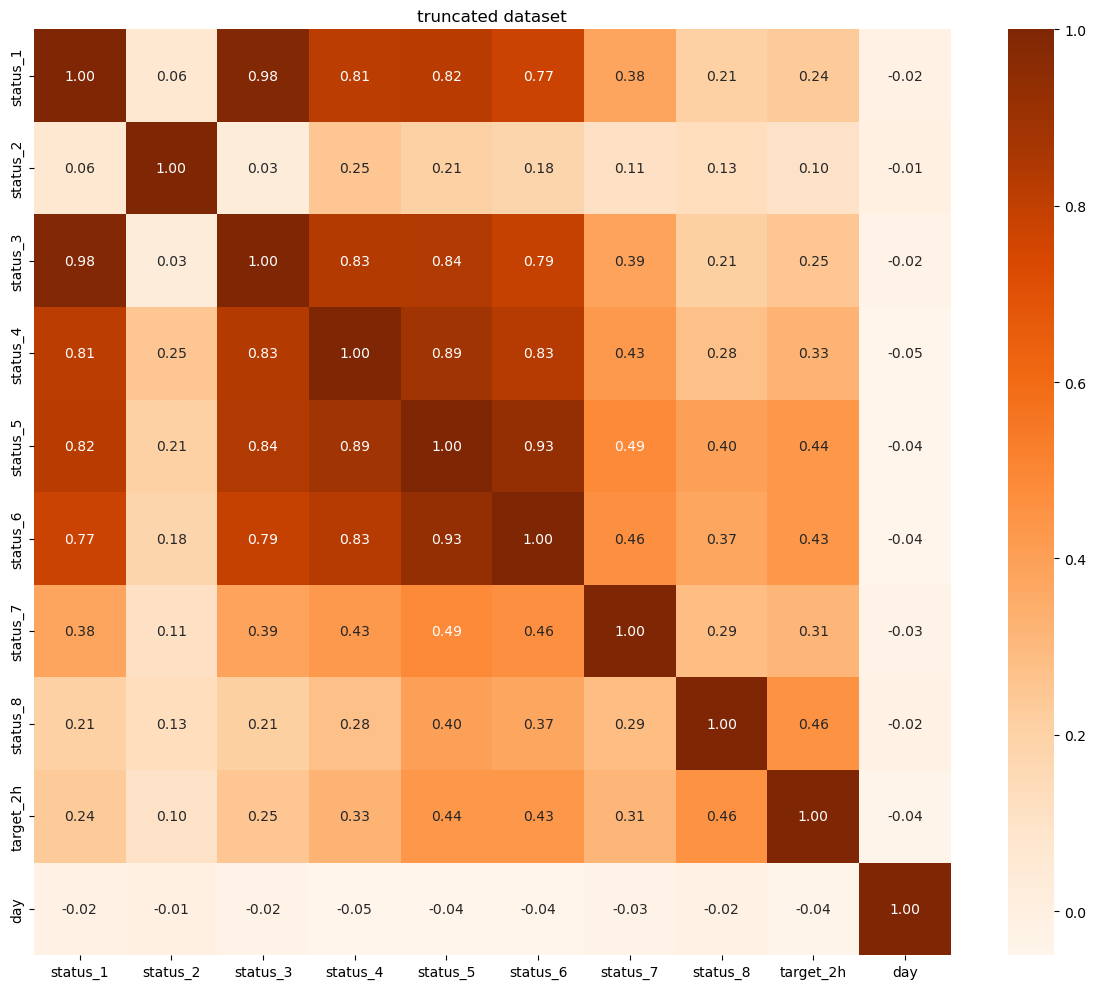

In [122]:
plt.figure(figsize=(12,10))
ax = sns.heatmap(data=corr_df_sample, annot=True, cmap='Oranges', fmt='.2f')
ax.set_xticklabels(ax.get_xticklabels(), fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=10)
plt.title('truncated dataset')

plt.tight_layout()
plt.show()

In [ ]:
def density(feature, df):
    sns.displot(
        data=df,
        x=feature,
        kind='kde',
        color='orange'
    )
    plt.xlabel(feature)
    plt.ylabel('density')
    plt.show()

In [124]:
def density_hist(feature, df):
    plt.hist(df[feature], bins=50, density=True)
    plt.xlabel(feature)
    plt.ylabel('density')
    plt.show()

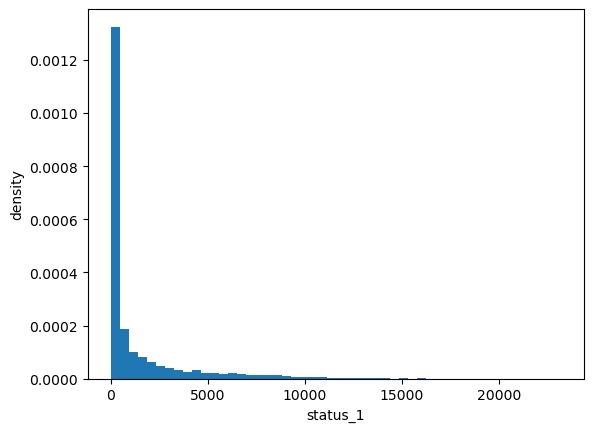

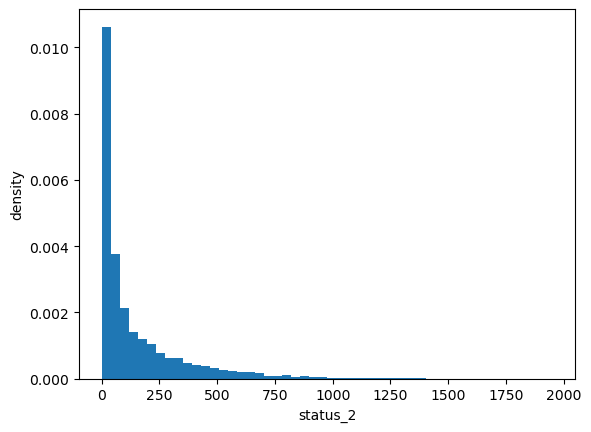

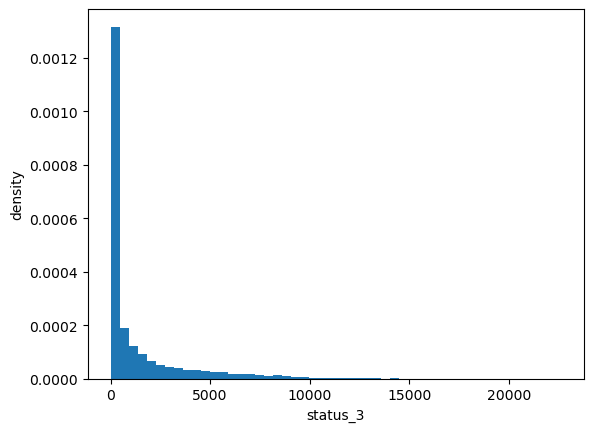

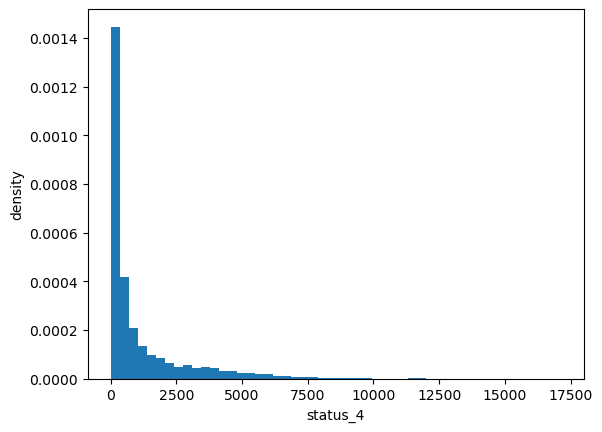

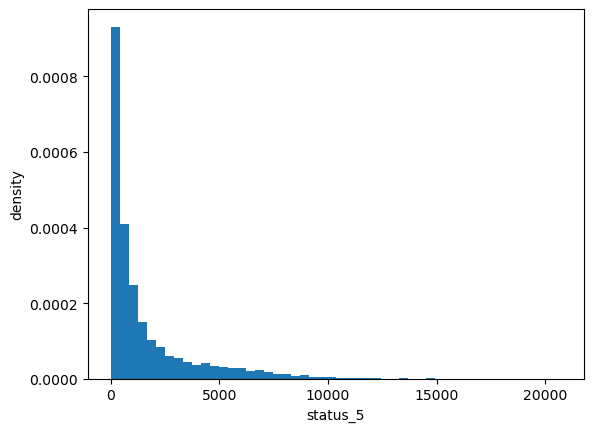

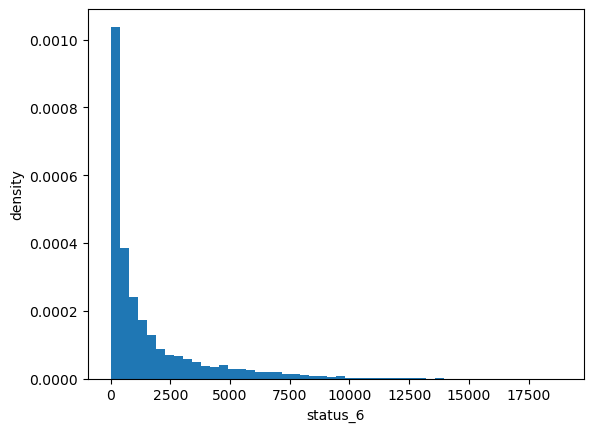

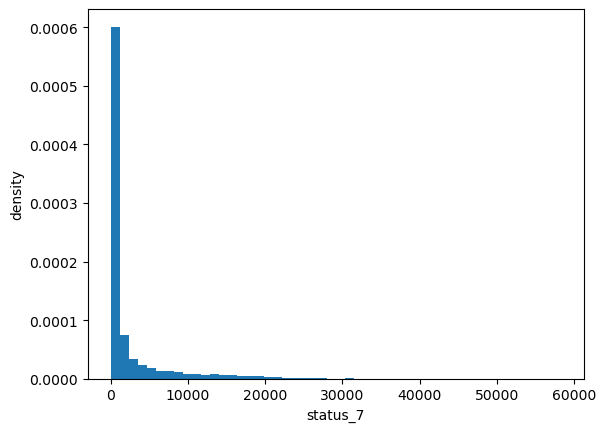

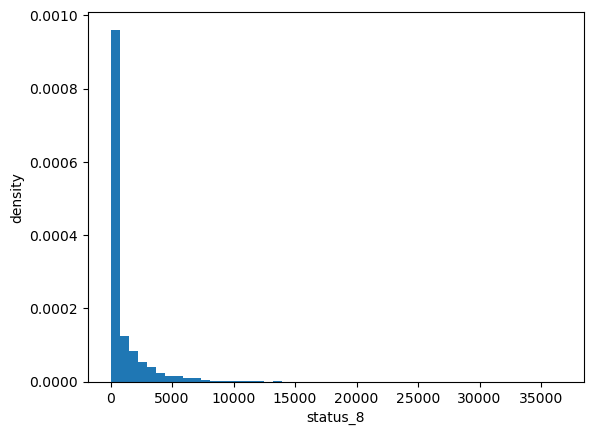

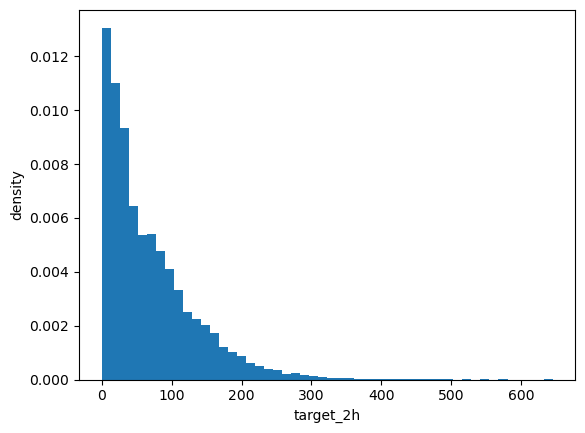

In [125]:
for feature in df_sample.columns[3:-1]:
    density_hist(feature, df_sample)

Никаких артефактов не видно, данные вполне логичны

In [134]:
df['hours'] = pd.to_datetime(df['timestamp']).dt.hour + pd.to_datetime(df['timestamp']).dt.minute/60
df['hours']

0           0.0
1           0.5
2           1.0
3           1.5
4           2.0
           ... 
4341995     8.5
4341996     9.0
4341997     9.5
4341998    10.0
4341999    10.5
Name: hours, Length: 4342000, dtype: float64

In [179]:
def density_dayweek_time():
    df_grouped_dayweek_time = df.groupby(['day', 'hours'])[variable_features[:-1]].mean().reset_index()
    
    _, axes = plt.subplots(9, 1, figsize=(15, 100))
    axes = axes.flatten()

    day_names = {0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun'}

    for i, feature in enumerate(variable_features[:-1]):
        for day in range(7):
            data = df_grouped_dayweek_time[df_grouped_dayweek_time['day'] == day]
            axes[i].plot(data['hours'], data[feature], label=day_names[day])

        axes[i].set_title(feature, fontsize=20)
        axes[i].set_xlabel('Hour', fontsize=16)
        axes[i].set_ylabel('Mean value', fontsize=16)
        axes[i].set_xticks(np.arange(0, 24, 0.5))
        axes[i].set_xticklabels([f'{int(h)}:{int((h%1)*60):02d}' for h in np.arange(0, 24, 0.5)], rotation=45)
        axes[i].legend()

    plt.tight_layout()
    plt.show()

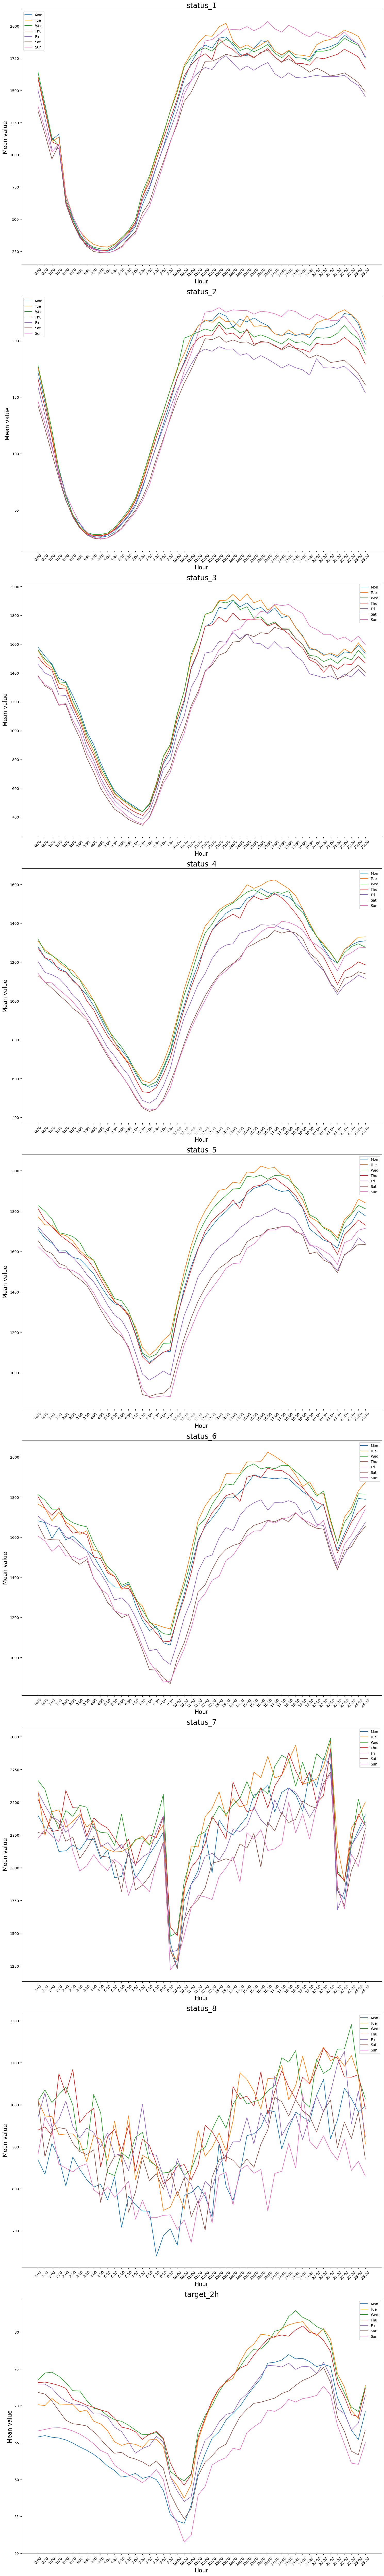

In [180]:
density_dayweek_time()

Как видно из графиков, в средних значениях статусов наблюдаются определённые тенденции:
- спад status_1 наблюдается с 0:00 до 5:00, рост с 5:00 до 14:00, потом незначительные колебания
- спад status_2 наблюдается с 0:00 до 4:30, рост с 4:30 до 12:00, потом незначительные колебания
- спад status_3 наблюдается с 0:00 до 7:30, рост с 7:30 до 14:00, потом спад с 14:00 до 0:00 следующего дня
- спад status_4 наблюдается с 0:00 до 8:00, рост с 8:00 до 17:00, потом спад с 17:00 до 21:30, потом рост до 0:00 следующего дня
- спад status_5 наблюдается с 0:00 до 8:00, рост с 8:00 до 16:00, потом спад с 16:00 до 21:00, потом рост до 0:00 следующего дня
- спад status_6 наблюдается с 0:00 до 9:30, рост с 9:40 до 16:30, потом спад с 16:30 до 21:30, потом рост до 0:00 следующего дня
- status_7 и status_8 проявляют себя очень нестабильно, постоянно скачут, но всё равно общий тренд отследить возможно
- у status_7 спад наблюдается с 0:00 до 10:30, причём с 8:30 до 10:30 очень резкий скачок вниз, там значение за 1.5 часа уменьшается на 1000, с 10:30 до 20:30 рост, а потом с 20:30 до 21:30 снова резкий скачок вниз, за 1 час уменьшается на 1000, дальше до 0:00 рост
- у status_8 очень большие колебания, но всё равно можно отследить некий тренд, с 0:00 до 10:30 спад, потом до следующего дня рост
- у target_2h наблюдается спад с 0:00 до 10:30, причём с 8:30 до 10:30 спад более резкий, чем до этого, рост с 10:30 до 18:30, потом снова спад с 18:30 до 23:00, дальше рост до 0:00 следующего дня

### Временные интервалы ключевых изменений
| Статус | Начало спада | Конец спада | Начало роста | Пик активности | Вечерний спад |
|--------|--------------|-------------|--------------|----------------|---------------|
| status_1 | 00:00 | 05:00 | 05:00 | 14:00 | - |
| status_2 | 00:00 | 04:30 | 04:30 | 12:00 | - |
| status_3 | 00:00 | 07:30 | 07:30 | 14:00 | с 14:00 |
| status_4 | 00:00 | 08:00 | 08:00 | 17:00 | 17:00-21:30 |
| status_5 | 00:00 | 08:00 | 08:00 | 16:00 | 16:00-21:00 |
| status_6 | 00:00 | 09:30 | 09:40 | 16:30 | 16:30-21:30 |
| status_7 | 00:00 | 10:30 | 10:30 | 20:30 | 20:30-21:30 |
| status_8 | 00:00 | 10:30 | 10:30 | 00:00 | - |
| target_2h | 00:00 | 10:30 | 10:30 | 18:30 | 18:30-23:00 |

### Сдвиг пиков активности
| Этап | Статусы | Пик активности | Относительно предыдущего |
|------|---------|----------------|--------------------------|
| Поступление | 1-3 | 12:00-14:00 | базовый |
| Обработка | 4-6 | 16:00-17:00 | +2-4 часа |
| Готовность | 7-8 | 20:30 | +4-6 часов |
| Отгрузка | target_2h | 18:30 | +2-4 часа |